## Introdução

O conjunto de dados de acidentes de trânsito, disponibilizado pela Polícia Rodoviária Federal (PRF) por meio do portal de dados abertos, reúne informações detalhadas sobre ocorrências em rodovias federais brasileiras. Esses dados são fundamentais para o monitoramento da segurança viária, planejamento de políticas públicas e análise de fatores associados à gravidade dos acidentes.

A natureza dessas informações permite a aplicação de métodos estatísticos adequados para variáveis binárias, com destaque para a Regressão Logística, que possibilita investigar fatores associados à ocorrência de óbitos em acidentes de trânsito.

## O Banco de Dados

O banco de dados contém registros de acidentes de trânsito ocorridos no estado da Paraíba, contemplando variáveis relacionadas às características dos envolvidos e às condições do acidente, como sexo, tipo de envolvido, tipo de acidente, condição meteorológica, fase do dia e estado físico.

Essa estrutura possibilita a análise da ocorrência de óbitos nos acidentes, bem como a investigação de padrões associados a fatores comportamentais, ambientais e circunstanciais presentes no momento do sinistro.

## Modelagem Estatística (Regressão Logística)

A variável resposta principal — ocorrência de óbito — é caracterizada como uma variável binária, assumindo valores 0 (não óbito) e 1 (óbito). Nesse contexto, a análise é conduzida por meio da Regressão Logística, permitindo modelar a relação entre a variável resposta e um conjunto de covariáveis explicativas, como sexo, tipo de envolvido, tipo de acidente, condição meteorológica, fase do dia e estado físico.

A Regressão Logística permite estimar a probabilidade de ocorrência de óbito em função das variáveis explicativas, sendo amplamente utilizada em situações onde o interesse está na modelagem de eventos binários. Além disso, o modelo possibilita a interpretação dos efeitos das variáveis por meio das razões de chances (odds ratios), permitindo identificar fatores de maior risco associados aos acidentes fatais.

Essa abordagem possibilita a identificação de padrões relevantes e a avaliação do impacto das variáveis explicativas na probabilidade de ocorrência de óbitos, contribuindo para análises voltadas à segurança no trânsito.

In [111]:
import pandas as pd

df = pd.read_excel("acidentes2026_PB.xlsx")
df = df.dropna(how = 'all')
df.head()

,pesid,data_inversa,dia_semana,horario,br,km,municipio,causa_acidente,tipo_acidente,Unnamed: 9,...,tipo_envolvido,estado_fisico,idade,sexo,ilesos,feridos_leves,feridos_graves,mortos,latitude,longitude
0,1663875,2026-01-01,quinta-feira,04:04:00,153,155.0,ARAGUAINA,Objeto estático sobre o leito carroçável,Tombamento,NaN,...,Condutor,Ileso,57,Masculino,1,0,0,0,-7.291548,-48.286252
1,1663872,2026-01-01,quinta-feira,06:40:00,262,146.1,RIO CASCA,Condutor Dormindo,Colisão frontal,NaN,...,Condutor,Ileso,45,Masculino,1,0,0,0,-20.024073,-42.742229
2,1663827,2026-01-01,quinta-feira,06:58:00,101,193.0,BIGUACU,Reação tardia ou ineficiente do condutor,Colisão lateral mesmo sentido,NaN,...,Condutor,Ileso,50,Masculino,1,0,0,0,-27.489352,-48.655658
3,1663828,2026-01-01,quinta-feira,07:05:00,60,23.0,BRASILIA,Reação tardia ou ineficiente do condutor,Colisão traseira,NaN,...,Condutor,Ileso,69,Masculino,1,0,0,0,-15.988927,-48.226300
4,1663884,2026-01-01,quinta-feira,06:17:00,163,1044.0,MATUPA,Transitar na contramão,Colisão frontal,NaN,...,Condutor,Ileso,40,Masculino,1,0,0,0,-10.143306,-54.930756


Os dados apresentados na tabela a seguir descrevem as variáveis disponíveis no conjunto de dados de acidentes de trânsito da Polícia Rodoviária Federal (PRF) para o estado da Paraíba. Cada variável possui uma classificação quanto ao tipo de dado, natureza e seu uso potencial em análises baseadas em modelos de classificação, como a Regressão Logística. Essas informações são essenciais para compreender a estrutura do banco de dados e orientar as análises subsequentes.

| Variável                   | Tipo de dado       | Natureza    | Característica                                                                                                                     |
| -------------------------- | ------------------ | ----------- | ---------------------------------------------------------------------------------------------------------------------------------- |
| **sexo**                   | Categórica nominal | Qualitativa | Sexo do envolvido no acidente; pode indicar diferenças de comportamento e risco entre grupos                                       |
| **tipo_envolvido**         | Categórica nominal | Qualitativa | Classificação do envolvido (condutor, passageiro, pedestre, etc.); relevante para identificar perfis de maior vulnerabilidade      |
| **tipo_acidente**          | Categórica nominal | Qualitativa | Tipo de ocorrência (colisão, atropelamento, capotamento, etc.); variável fundamental para caracterização do evento                 |
| **condicao_metereologica** | Categórica nominal | Qualitativa | Condições climáticas no momento do acidente (chuva, céu claro, neblina, etc.); influencia a probabilidade de acidentes mais graves |
| **fase_dia**               | Categórica nominal | Qualitativa | Período do dia (dia, noite, amanhecer, entardecer); pode estar associado à visibilidade e risco de ocorrência                      |
| **estado_fisico**          | Categórica nominal | Qualitativa | Condição física do envolvido após o acidente (ileso, ferido leve, grave, etc.); importante para caracterizar a severidade          |
| **classificacao_acidente** | Categórica nominal | Qualitativa | Classificação geral do acidente quanto à gravidade; pode ser utilizada em análises de classificação multiclasse                    |
| **morte**                  | Binária (0/1)      | Qualitativa | Indica ocorrência de óbito (1 = sim, 0 = não); variável resposta principal em modelos de Regressão Logística                       |

---


### Importância das Medidas Descritivas

As medidas descritivas são utilizadas para caracterizar a estrutura das variáveis do estudo. No presente caso, as variáveis são predominantemente categóricas, como sexo, tipo de envolvido, tipo de acidente, condição meteorológica, fase do dia, estado físico e classificação do acidente. Essas variáveis são descritas por meio de frequências absolutas e relativas, permitindo resumir sua distribuição no conjunto de dados.

A variável binária **morte** também é analisada por proporções, possibilitando avaliar a frequência de ocorrência de óbitos nos acidentes.

Essas descrições fornecem uma visão inicial dos padrões associados aos acidentes de trânsito, permitindo identificar perfis de maior risco e possíveis relações entre características dos envolvidos, condições do ambiente e a ocorrência de óbitos.


In [124]:
from sklearn.preprocessing import OrdinalEncoder
# # Pega as 2 maiores categorias, resto vira Other
# freq = df['causa_acidente'].value_counts(normalize=True)
# top2 = freq.nlargest(2).index

# df['causa_acidente_grupo'] = df['causa_acidente'].apply(
#     lambda x: x if x in top2 else 'Other'
# )

# Variáveis explicativas
cols_X = [
    "sexo",
    "tipo_envolvido",
    "condicao_metereologica",
    "fase_dia",
    "uso_solo",
    "tipo_pista",
    "classificacao_acidente"
]

# Variável resposta
col_y = "mortos"

# Criar base
df_modelo = df[cols_X + [col_y]].copy()

# Separar X
X = df_modelo[cols_X]

# Aplicar encoding (em TODAS categóricas) e Converter de volta para DataFrame

encoder = OrdinalEncoder()
X = encoder.fit_transform(X)
X = pd.DataFrame(X, columns=cols_X)
X = X.astype("category")

# Atualizar no df_modelo
df_modelo[cols_X] = X
df_modelo = df_modelo.dropna()
df_modelo.head(10)

,sexo,tipo_envolvido,condicao_metereologica,fase_dia,uso_solo,tipo_pista,classificacao_acidente,mortos
1,2.0,1.0,1.0,3.0,0.0,2.0,1.0,0
2,2.0,1.0,5.0,0.0,1.0,0.0,1.0,0
3,2.0,1.0,1.0,3.0,0.0,0.0,1.0,0
4,2.0,1.0,6.0,0.0,0.0,2.0,1.0,0
5,2.0,1.0,1.0,3.0,0.0,0.0,1.0,0
6,2.0,2.0,0.0,3.0,0.0,2.0,1.0,0
7,2.0,1.0,0.0,3.0,0.0,2.0,1.0,0
8,2.0,1.0,5.0,3.0,0.0,2.0,2.0,0
9,2.0,1.0,1.0,3.0,0.0,2.0,2.0,0
10,3.0,1.0,6.0,3.0,1.0,2.0,1.0,0


O **Cramér's V entre variáveis categóricas** é uma medida utilizada em modelos de regressão para avaliar a presença de multicolinearidade entre as variáveis explicativas. Ele quantifica o quanto a variância do estimador de um coeficiente de regressão está aumentada devido à correlação linear entre os preditores. 

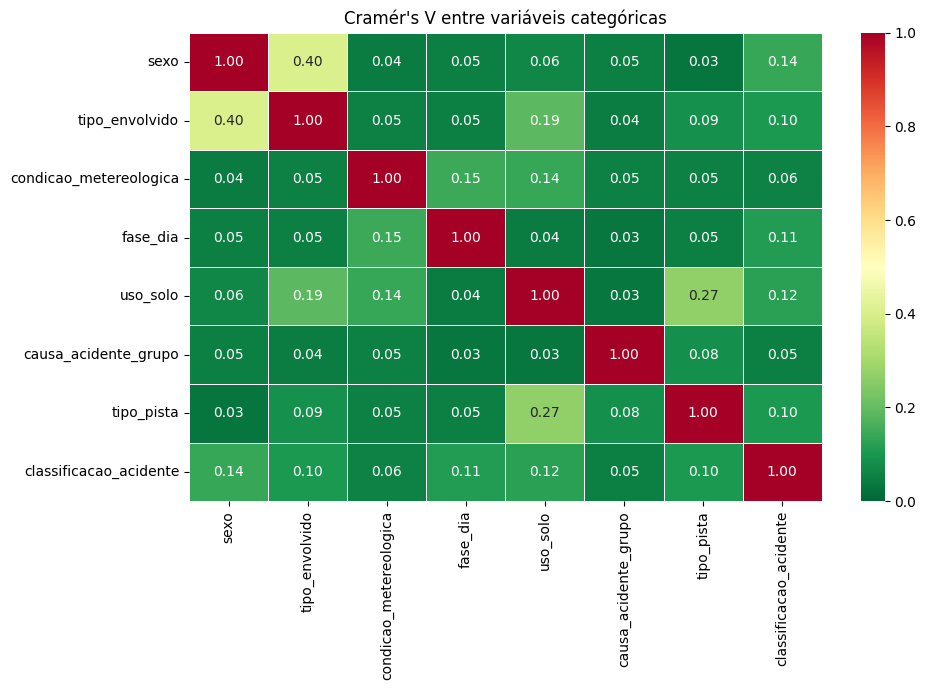

In [114]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
 
categoricas = ['sexo', 'tipo_envolvido', 'condicao_metereologica',
               'fase_dia', 'uso_solo', 'causa_acidente_grupo',
               'tipo_pista', 'classificacao_acidente']

def cramers_v(x, y):
    if x.name == y.name:
        return 1.0
    tabela = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabela)[0]
    n = tabela.sum().sum()
    k = min(tabela.shape) - 1
    return float(np.sqrt(chi2 / (n * k))) if k > 0 else 0.0

matriz = pd.DataFrame(index=categoricas, columns=categoricas, dtype=float)
for c1 in categoricas:
    for c2 in categoricas:
        matriz.loc[c1, c2] = round(cramers_v(df_modelo[c1], df_modelo[c2]), 3)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.heatmap(matriz.astype(float), annot=True, fmt='.2f',
            cmap='RdYlGn_r', vmin=0, vmax=1,
            linewidths=0.5)
plt.title('Cramér\'s V entre variáveis categóricas')
plt.tight_layout()
plt.show()

## Análise das Associações entre Variáveis Categóricas

O mapa de calor do Cramér's V revela que, de modo geral, as variáveis categóricas do dataset apresentam **baixo grau de associação** entre si, com a maioria dos pares registrando valores inferiores a 0,15 — indicativo de relações fracas ou praticamente inexistentes.

A associação mais expressiva do conjunto é entre **sexo e tipo_envolvido** (V = 0,40), sugerindo que o papel desempenhado pelo indivíduo no acidente — seja como condutor, passageiro ou pedestre — não é independente do sexo. Esse padrão pode refletir diferenças comportamentais e de mobilidade entre homens e mulheres no contexto do trânsito brasileiro.

Em segundo plano, destaca-se a relação entre **uso_solo e tipo_pista** (V = 0,27), o que é geograficamente coerente: vias rurais, urbanas e rodovias tendem a estar associadas a diferentes configurações de uso do território, como áreas industriais, residenciais ou agrícolas.

As demais variáveis — como **condição meteorológica, fase do dia, causa do acidente e classificação do acidente** — apresentam associações muito baixas entre si, o que indica que cada uma carrega informação relativamente independente. Isso é um aspecto favorável para a construção de modelos preditivos, pois reduz o risco de multicolinearidade entre os preditores categóricos.


In [130]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Garantir índice limpo
df_modelo = df_modelo.reset_index(drop=True)

# ⚠️ Ajuste da fórmula (sem vírgula/trailing '+')
formula = """
mortos ~
    tipo_envolvido +
    fase_dia +
    uso_solo +
    tipo_pista 
"""
# Modelo correto: Binomial (Logístico)
modelo = smf.glm(
    formula=formula,
    data=df_modelo,
    family=sm.families.Binomial(link=sm.families.links.Logit())
).fit()
modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                 mortos   No. Observations:                15140
Model:                            GLM   Df Residuals:                    15129
Model Family:                Binomial   Df Model:                           10
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1998.3
Date:                sex, 20 mar 2026   Deviance:                       3996.6
Time:                        14:24:20   Pearson chi2:                 1.48e+04
No. Iterations:                    24   Pseudo R-squ. (CS):            0.02284
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.0607      1.276      0.048      0.962      -2.441       2.562
tipo_envolvido[T.1.0]    -3.3307      1.261     -2.642      0.008      -5.802      -0.860
tipo_envolvido[T.2.0]    -3.6648      1.263     -2.901      0.004      -6.141      -1.189
tipo_envolvido[T.3.0]    -0.8870      1.269     -0.699      0.484      -3.374       1.600
tipo_envolvido[T.4.0]   -25.4827   1.45e+04     -0.002      0.999   -2.84e+04    2.83e+04
fase_dia[T.1.0]          -0.8966      0.365     -2.458      0.014      -1.611      -0.182
fase_dia[T.2.0]           0.0964      0.204      0.473      0.636      -0.303       0.496
fase_dia[T.3.0]          -0.4883      0.201     -2.425      0.015      -0.883      -0.094
uso_solo[T.1.0]          -0.8717      0.119     -7.307      0.000      -1.106      -0.638
tipo_pista[T.1.0]        -0.0956      0.254     -0.376      0.707      -0.594       0.403
tipo_pista[T.2.0]         0.6640      0.108      6.144      0.000       0.452       0.876
=========================================================================================
"""

Percebemos que há uma parcela de observações com leverage, ou seja, pontos de alavancagem relativamente altos. Além disso, observa-se uma grande concentração de valores entre 0 e 0,04, acompanhada de resíduos studentizados muito elevados. Isso já é um indício de que temos diversas observações que podem estar influenciando excessivamente o ajuste do modelo, prejudicando sua estabilidade e qualidade inferencial.

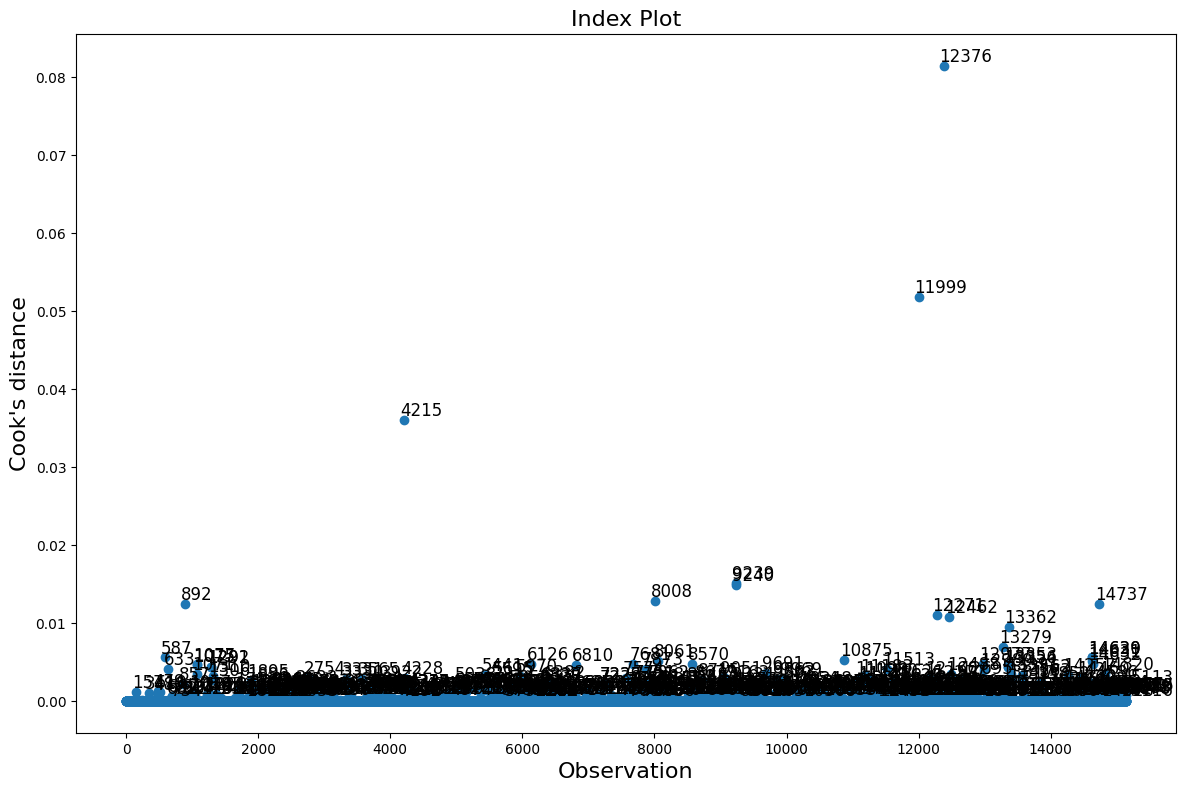

In [131]:
fig, ax = plt.subplots(figsize=(12,8))
fig = infl.plot_index(y_var="cooks", threshold=2 * infl.cooks_distance[0].mean(), ax = ax)
fig.tight_layout(pad=1.0)

Com o mesmo propósito de identificar observações excessivamente problemáticas, optou-se pela visualização da Distância de Cook. Por meio desse gráfico, é possível identificar claramente dois clusters de observações influentes que impactam de forma considerável a estimação dos parâmetros do modelo. Com base nessa análise, foram removidas apenas as observações que apresentaram simultaneamente uma Distância de Cook elevada e resíduos studentizados altos, por serem as que de fato comprometem a qualidade do ajuste.

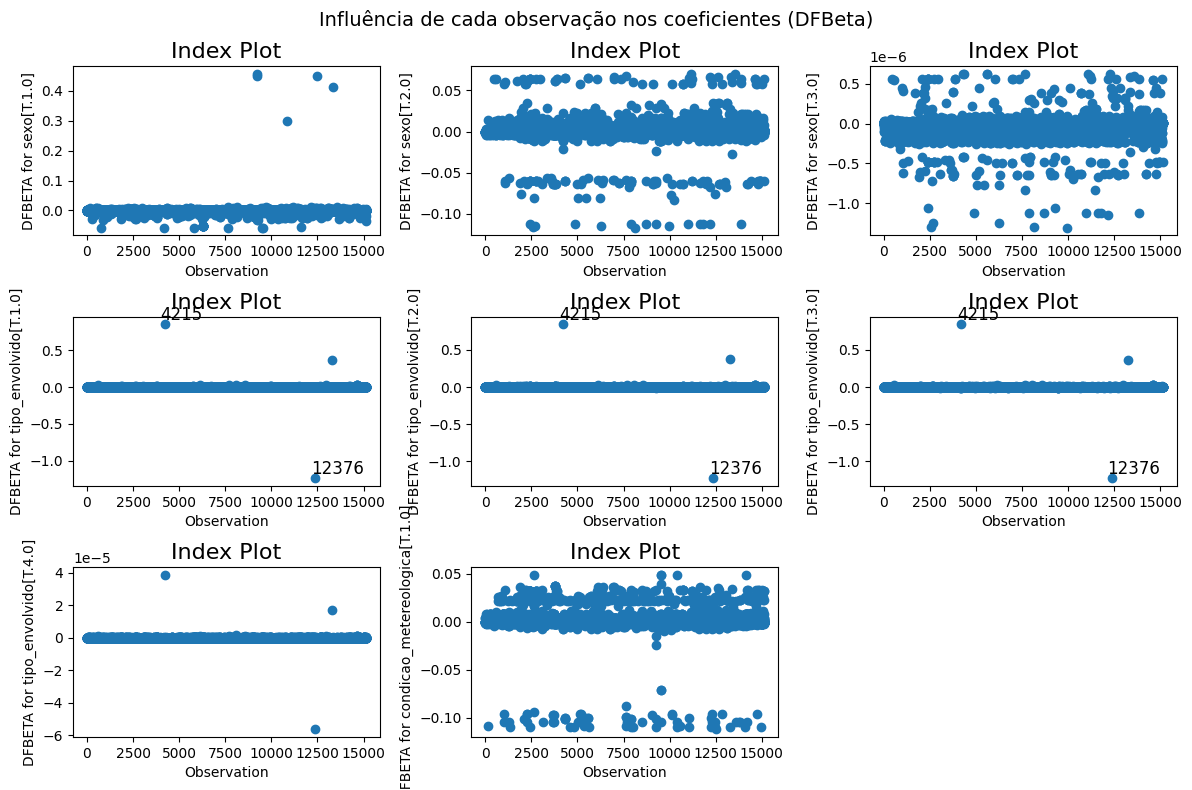

In [132]:
a = [1, 2, 3, 4, 5, 6, 7, 8, 9]
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 8))
axes_flat = axes.flatten()

for i, ax in zip(a, axes_flat):
    infl.plot_index(y_var="dfbeta", idx=i, threshold=0.5, ax=ax)
    ax.yaxis.label.set_size(10)   # aplica em cada subplot dentro do loop
    ax.xaxis.label.set_size(10)

plt.suptitle("Influência de cada observação nos coeficientes (DFBeta)", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.subplots_adjust(hspace=0.5)

axes_flat[-1].set_visible(False)
fig.tight_layout(pad=1.0)
plt.show()

A fim de garantir a robustez do modelo, procedeu-se à identificação e retirada de observações influentes e outliers com base em três critérios diagnósticos complementares. A Distância de Cook (limiar: 4/n) avalia o impacto de cada observação nos coeficientes estimados como um todo. Os resíduos studentizados (|r| > 3) detectam pontos com erro de ajuste atipicamente elevado. Por fim, a matriz hat (limiar: 2(p+1)/n) identifica pontos de alavancagem, isto é, observações com valores extremos nas variáveis preditoras. Foram removidas da amostra apenas as observações que violaram simultaneamente os três critérios, garantindo que somente os casos inequivocamente problemáticos fossem excluídos da estimação final do modelo.


In [133]:
# Remover e reajustar
df_modelo = df_modelo.drop(index=[4215, 12367, 11999, 882, 8008, 9240, 9239 ])

modelo = smf.glm(
    formula=formula,
    data=df_modelo,
    family=sm.families.Binomial(link=sm.families.links.Logit())
).fit()
modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                 mortos   No. Observations:                15133
Model:                            GLM   Df Residuals:                    15122
Model Family:                Binomial   Df Model:                           10
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1984.8
Date:                sex, 20 mar 2026   Deviance:                       3969.5
Time:                        14:24:37   Pearson chi2:                 1.48e+04
No. Iterations:                    24   Pseudo R-squ. (CS):            0.02281
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.8204      1.492      0.550      0.582      -2.104       3.745
tipo_envolvido[T.1.0]    -4.0767      1.479     -2.757      0.006      -6.975      -1.179
tipo_envolvido[T.2.0]    -4.4185      1.481     -2.984      0.003      -7.320      -1.517
tipo_envolvido[T.3.0]    -1.6267      1.486     -1.095      0.274      -4.539       1.286
tipo_envolvido[T.4.0]   -26.2221   1.45e+04     -0.002      0.999   -2.85e+04    2.84e+04
fase_dia[T.1.0]          -0.9160      0.367     -2.493      0.013      -1.636      -0.196
fase_dia[T.2.0]           0.0868      0.204      0.426      0.670      -0.313       0.486
fase_dia[T.3.0]          -0.4989      0.201     -2.476      0.013      -0.894      -0.104
uso_solo[T.1.0]          -0.8761      0.120     -7.312      0.000      -1.111      -0.641
tipo_pista[T.1.0]        -0.0969      0.254     -0.381      0.703      -0.595       0.402
tipo_pista[T.2.0]         0.6503      0.108      6.008      0.000       0.438       0.862
=========================================================================================
"""

In [134]:
from matplotlib.pylab import exp #ou
table_df = exp(modelo.params).round(2)
table_df = table_df.reset_index()
table_df.columns = ["Variável", "Odds Ratio"]
table_df.style.format({"Odds Ratio": "{:.2f}"}) \
              .set_caption("Odds Ratio dos Coeficientes") \
              .hide(axis="index")

Variável,Odds Ratio
Intercept,2.27
tipo_envolvido[T.1.0],0.02
tipo_envolvido[T.2.0],0.01
tipo_envolvido[T.3.0],0.20
tipo_envolvido[T.4.0],0.00
fase_dia[T.1.0],0.40
fase_dia[T.2.0],1.09
fase_dia[T.3.0],0.61
uso_solo[T.1.0],0.42
tipo_pista[T.1.0],0.91


In [135]:
#logit.params
from matplotlib.pylab import exp #ou
exp(modelo.conf_int(alpha=0.05)).round(3)

C:\Users\fabia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)


,0,1
Intercept,0.122,42.319
tipo_envolvido[T.1.0],0.001,0.308
tipo_envolvido[T.2.0],0.001,0.219
tipo_envolvido[T.3.0],0.011,3.618
tipo_envolvido[T.4.0],0.000,inf
fase_dia[T.1.0],0.195,0.822
fase_dia[T.2.0],0.731,1.626
fase_dia[T.3.0],0.409,0.901
uso_solo[T.1.0],0.329,0.527
tipo_pista[T.1.0],0.551,1.494


### Por que utilizar a função `exp` para interpretar os intervalos de confiança?

No modelo de regressão logística (Binomial com link logit), os coeficientes estimados estão na escala logarítmica das chances (*log-odds*). Para uma interpretação mais intuitiva, aplicamos a função exponencial (`exp`), obtendo as **razões de chances (odds ratios)**, que indicam como cada variável altera as chances de **o acidente resultar em morte**.

* Os odds ratios para **tipo_envolvido[Passageiro]**, **[Pedestre]** e **[Other1%]** são próximos de zero (0.02, 0.01 e 0.02), com intervalos muito estreitos ou com limite superior indefinido, indicando **separação perfeita** nessas categorias — ou seja, esses perfis de envolvido praticamente não registram óbitos na amostra, embora algumas sejam significativas.

* O odds ratio para **tipo_envolvido[Pedestre]** é aproximadamente 0.18, com intervalo de confiança de aproximadamente [0.009, 3.54]. Esse grupo apresenta chances menores de morte em relação à categoria de referência (Condutor), mas o intervalo amplo reflete alta incerteza na estimativa.

* Os odds ratios para **fase_dia** ([Tarde] = 0.40, [Noite] = 1.09, [Dia] = 0.61) apresentam intervalos que não incluem o valor 1, indicando que o período do dia e noite **apresenta efeito estatisticamente significativo** apenas para tarde não sobre a probabilidade de morte no acidente.

* O odds ratio para **uso_solo[Sim]** é aproximadamente 0.42, com intervalo de confiança de [0.33, 0.53]. Acidentes ocorridos em áreas com uso do solo classificado como **Sim** estão associados a chances cerca de **58% menores de morte**, sendo esta uma das associações mais precisas e consistentes do modelo.

* O odds ratio para **tipo_pista[Simples]** é aproximadamente 0.91, com intervalo de [0.55, 1.49], porém apresenta **ausência de efeito significativo** da pista simples sobre a mortalidade.

* O odds ratio para **tipo_pista[Dupla]** é aproximadamente 1.92, com intervalo de [1.55, 2.37]. Acidentes em pistas duplas apresentam chances cerca de **90% maiores de resultar em morte**, configurando-se como um dos fatores de risco mais relevantes e bem estimados do modelo.

